# Figure 2D. Species by body site upset plot

In [155]:
# map from original id to species
import polars as pl

seqhasher = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/hq_hc_viruses_seqhasher.tsv.gz', separator='\t').unique('original_id')
uhvdb_mapping = pl.concat([
    pl.read_csv('../figure_1/uhvdb_virus_db_results/uhvdb_2026-03-26/uhvdb_mapping.tsv.gz', separator='\t'),
    pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/new_hq_hc_viruses_mapping.tsv.gz', separator='\t')
])
seqhash_reps = seqhasher.filter(pl.col('original_id').is_in(set(uhvdb_mapping['original_id']))).unique('original_id').rename({'original_id':'seqhash_rep'})
uhvdb_source_meta = pl.read_csv('../figure_1/uhvdb_final_metadata.tsv', separator='\t')
genomovar_info = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/genomovars_cluster/hq_hc_genomovars_info.tsv.gz', separator='\t')
uhvdb_species_info = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/species_cluster/hq_hc_species_info.tsv.gz', separator='\t')
aaicluster = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/aaicluster/hq_hc_species_aai_clusters.tsv.gz', separator='\t')

combined = (
    uhvdb_source_meta
        .join(seqhasher.unique('original_id'), left_on='seq_name', right_on='original_id', how='left')
        .join(seqhasher.with_columns(pl.col('original_id').str.extract(r"^(.*)\|provirus", group_index=1).fill_null(pl.col("original_id"))), left_on='seq_name', right_on='original_id', how='left')
        .with_columns(
            pl.when(pl.col('hash').is_not_null()).then(pl.col('hash')).otherwise(pl.col('hash_right')).alias('hash')
        )
        .join(seqhash_reps, on='hash', how='left')
        .join(uhvdb_mapping.unique('original_id'), left_on='seqhash_rep', right_on='original_id', how='left')
        .join(genomovar_info[['uhvdb_id', 'votu_rep']], left_on='new_id', right_on='uhvdb_id', how='left').rename({'votu_rep':'genomovar_rep'})
        .join(uhvdb_species_info[['uhvdb_id', 'votu_rep']], left_on='genomovar_rep', right_on='uhvdb_id', how='left')
        .join(aaicluster, left_on='votu_rep', right_on='uhvdb_id', how='left')
        .unique('seq_name')
)
combined.write_csv('uhvdb_cluster_mapping.tsv', separator='\t')

In [156]:
combined.group_by('body_site').len()

body_site,len
str,u32
"""Skin""",26677
"""Gut""",416620
"""Urogenital""",10599
"""Other""",64451
"""Airways""",242346


In [171]:
# calculate proportion body site agreement within hashes
hash_body_site_agreement = (
    combined
    .filter(pl.col('hash').is_not_null() & (pl.col('body_site') != 'Other'))
    .group_by(['hash', 'body_site'])
    .agg(pl.len().alias('n_seqs_body_site'))
    .group_by('hash')
    .agg([
        pl.col('n_seqs_body_site').max().alias('max_body_site_count'),
        pl.col('n_seqs_body_site').sum().alias('total_seqs_in_hash'),
        pl.col('body_site').sort_by('n_seqs_body_site', descending=True).first().alias('top_body_site'),
        pl.col('n_seqs_body_site').sort(descending=True).first().alias('top_body_site_count')
    ])
    .filter(pl.col('total_seqs_in_hash') > 1)
    .with_columns(
        (pl.col('max_body_site_count') / pl.col('total_seqs_in_hash')).alias('body_site_agreement')
    )
    .sort('body_site_agreement', descending=True)
)

hash_body_site_agreement['body_site_agreement'].describe()
print(hash_body_site_agreement.filter(pl.col('body_site_agreement') == 1).shape[0], "/",
    hash_body_site_agreement.shape[0],
    "hashes with perfect body site agreement")

120088 / 122166 hashes with perfect body site agreement


In [176]:
# calculate proportion body site agreement within genomovars
genomovar_body_site_agreement = (
    combined
    .filter(pl.col('genomovar_rep').is_not_null() & (pl.col('body_site') != 'Other'))
    .group_by(['genomovar_rep', 'body_site'])
    .agg(pl.len().alias('n_seqs_body_site'))
    .group_by('genomovar_rep')
    .agg([
        pl.col('n_seqs_body_site').max().alias('max_body_site_count'),
        pl.col('n_seqs_body_site').sum().alias('total_seqs_in_genomovar'),
        pl.col('body_site').sort_by('n_seqs_body_site', descending=True).first().alias('top_body_site'),
        pl.col('n_seqs_body_site').sort(descending=True).first().alias('top_body_site_count')
    ])
    .filter(pl.col('total_seqs_in_genomovar') > 1)
    .with_columns(
        (pl.col('max_body_site_count') / pl.col('total_seqs_in_genomovar')).alias('body_site_agreement')
    )
    .sort('body_site_agreement', descending=True)
)

genomovar_body_site_agreement['body_site_agreement'].describe()
print(genomovar_body_site_agreement.filter(pl.col('body_site_agreement') == 1).shape[0] / genomovar_body_site_agreement.shape[0],
    "hashes with perfect body site agreement")

0.9804560529994127 hashes with perfect body site agreement


In [177]:
# calculate proportion body site agreement within species
species_body_site_agreement = (
    combined
    .filter(pl.col('votu_rep').is_not_null() & (pl.col('body_site') != 'Other'))
    .group_by(['votu_rep', 'body_site'])
    .agg(pl.len().alias('n_seqs_body_site'))
    .group_by('votu_rep')
    .agg([
        pl.col('n_seqs_body_site').max().alias('max_body_site_count'),
        pl.col('n_seqs_body_site').sum().alias('total_seqs_in_species'),
        pl.col('body_site').sort_by('n_seqs_body_site', descending=True).first().alias('top_body_site'),
        pl.col('n_seqs_body_site').sort(descending=True).first().alias('top_body_site_count')
    ])
    .filter(pl.col('total_seqs_in_species') > 1)
    .with_columns(
        (pl.col('max_body_site_count') / pl.col('total_seqs_in_species')).alias('body_site_agreement')
    )
    .sort('body_site_agreement', descending=True)
)

species_body_site_agreement['body_site_agreement'].describe()
print(species_body_site_agreement.filter(pl.col('body_site_agreement') == 1).shape[0] / species_body_site_agreement.shape[0],
    "hashes with perfect body site agreement")

0.9396972997123789 hashes with perfect body site agreement


In [178]:
# calculate proportion body site agreement within genera
genus_body_site_agreement = (
    combined
    .filter(pl.col('genus_cluster_id').is_not_null() & (pl.col('body_site') != 'Other'))
    .group_by(['genus_cluster_id', 'body_site'])
    .agg(pl.len().alias('n_seqs_body_site'))
    .group_by('genus_cluster_id')
    .agg([
        pl.col('n_seqs_body_site').max().alias('max_body_site_count'),
        pl.col('n_seqs_body_site').sum().alias('total_seqs_in_genus'),
        pl.col('body_site').sort_by('n_seqs_body_site', descending=True).first().alias('top_body_site'),
        pl.col('n_seqs_body_site').sort(descending=True).first().alias('top_body_site_count')
    ])
    .filter(pl.col('total_seqs_in_genus') > 1)
    .with_columns(
        (pl.col('max_body_site_count') / pl.col('total_seqs_in_genus')).alias('body_site_agreement')
    )
    .sort('body_site_agreement', descending=True)
)

genus_body_site_agreement['body_site_agreement'].describe()
print(genus_body_site_agreement.filter(pl.col('body_site_agreement') == 1).shape[0] / genus_body_site_agreement.shape[0],
    "hashes with perfect body site agreement")

0.8777442961687473 hashes with perfect body site agreement


In [179]:
# calculate proportion body site agreement within families
family_body_site_agreement = (
    combined
    .filter(pl.col('family_cluster_id').is_not_null() & (pl.col('body_site') != 'Other'))
    .group_by(['family_cluster_id', 'body_site'])
    .agg(pl.len().alias('n_seqs_body_site'))
    .group_by('family_cluster_id')
    .agg([
        pl.col('n_seqs_body_site').max().alias('max_body_site_count'),
        pl.col('n_seqs_body_site').sum().alias('total_seqs_in_family'),
        pl.col('body_site').sort_by('n_seqs_body_site', descending=True).first().alias('top_body_site'),
        pl.col('n_seqs_body_site').sort(descending=True).first().alias('top_body_site_count')
    ])
    .filter(pl.col('total_seqs_in_family') > 1)
    .with_columns(
        (pl.col('max_body_site_count') / pl.col('total_seqs_in_family')).alias('body_site_agreement')
    )
    .sort('body_site_agreement', descending=True)
)

family_body_site_agreement['body_site_agreement'].describe()
print(family_body_site_agreement.filter(pl.col('body_site_agreement') == 1).shape[0] / family_body_site_agreement.shape[0],
    "hashes with perfect body site agreement")

0.4885193982581156 hashes with perfect body site agreement


In [162]:
combined.group_by('family_cluster_id').len().describe()

statistic,family_cluster_id,len
str,f64,f64
"""count""",1444.0,1444.0
"""null_count""",0.0,0.0
"""mean""",722.5,526.795706
"""std""",416.991207,1806.417861
"""min""",1.0,1.0
"""25%""",362.0,5.0
"""50%""",723.0,34.0
"""75%""",1083.0,236.0
"""max""",1444.0,31339.0


In [163]:
skin_seqs = set(combined.filter(pl.col('body_site') == 'Skin')['new_id'])
urogenital_seqs = set(combined.filter(pl.col('body_site') == 'Urogenital')['new_id'])
gut_seqs = set(combined.filter(pl.col('body_site') == 'Gut')['new_id'])
airway_seqs = set(combined.filter(pl.col('body_site') == 'Airways')['new_id'])

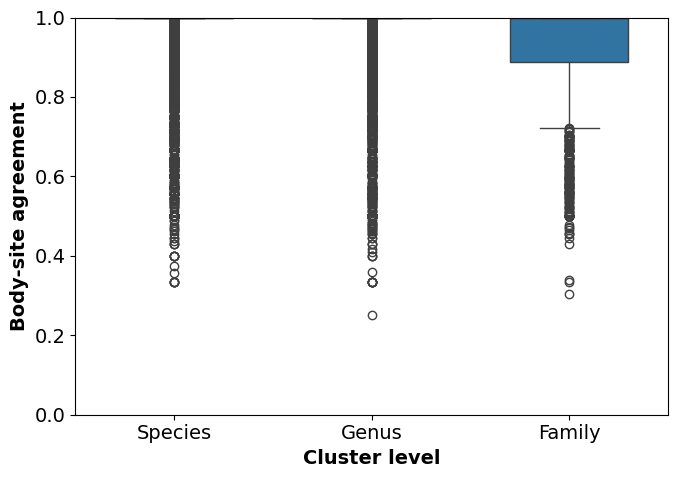

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

# Prepare long-format table for plotting
agreement_long = pl.concat([
    species_body_site_agreement.select(
        pl.lit("Species").alias("cluster_level"),
        pl.col("body_site_agreement").alias("agreement")
    ),
    genus_body_site_agreement.select(
        pl.lit("Genus").alias("cluster_level"),
        pl.col("body_site_agreement").alias("agreement")
    ),
    family_body_site_agreement.select(
        pl.lit("Family").alias("cluster_level"),
        pl.col("body_site_agreement").alias("agreement")
    )
])

plot_df = agreement_long.to_pandas()

plt.figure(figsize=(7, 5))
sns.boxplot(
    data=plot_df,
    x="cluster_level",
    y="agreement",
    order=["Species", "Genus", "Family"],
    width=0.6,
    showfliers=True
)

plt.xlabel("Cluster level", fontdict={'fontweight': 'bold'})
plt.ylabel("Body-site agreement", fontdict={'fontweight': 'bold'})
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

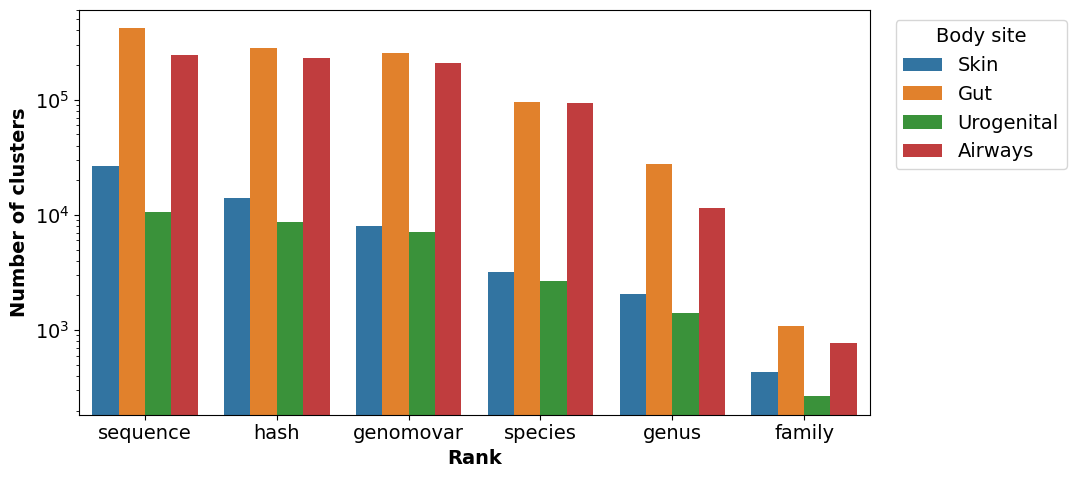

In [165]:
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

site_filter = pl.col('body_site').is_not_null() & (pl.col('body_site') != 'Other')
rank_specs = [
    ('sequence', 'seq_name'),
    ('hash', 'hash'),
    ('genomovar', 'genomovar_rep'),
    ('species', 'votu_rep'),
    ('genus', 'genus_cluster_id'),
    ('family', 'family_cluster_id'),
]

rank_counts = pl.concat([
    combined.filter(site_filter & pl.col(colname).is_not_null()).group_by('body_site').agg(
        pl.col(colname).n_unique().alias('n_clusters')
    ).with_columns(pl.lit(rank_label).alias('rank'))
    for rank_label, colname in rank_specs
], how='vertical').select(['rank', 'body_site', 'n_clusters'])

total_counts = pl.DataFrame([
    {
        'rank': rank_label,
        'total_clusters': combined.filter(site_filter & pl.col(colname).is_not_null())[colname].n_unique()
    }
    for rank_label, colname in rank_specs
])

site_order = [s for s in ['Skin', 'Gut', 'Urogenital', 'Airways', 'Other'] if s in rank_counts['body_site'].unique().to_list()]
plot_df = rank_counts.join(total_counts, on='rank', how='left').to_pandas()
label_order = total_counts.to_dicts()

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=plot_df,
    x='rank',
    y='n_clusters',
    hue='body_site',
    order=[r for r, _ in rank_specs],
    hue_order=site_order,
    ax=ax,
)

ax.set_xlabel('Rank', fontdict={'fontweight': 'bold'})
ax.set_ylabel('Number of clusters', fontdict={'fontweight': 'bold'})
ax.set_yscale('log')
ax.legend(title='Body site', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

/gscratch/pedslabs_hoffman/carsonjm/micromamba_envs/envs/lgonsa/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/gscratch/pedslabs_hoffman/carsonjm/micromamba_envs/envs/lgonsa/lib/python3.12/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never w

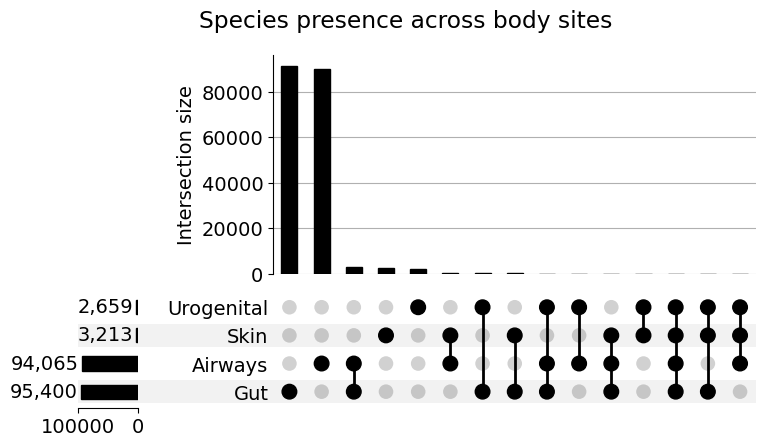

In [166]:
# Build species x body-site presence/absence matrix for UpSet
import polars as pl

upset_data = (
    combined
    .select(["votu_rep", "body_site"])
    .filter(pl.col("votu_rep").is_not_null() & pl.col("body_site").is_not_null() & (pl.col("body_site") != "Other"))
    .unique()
    .with_columns(pl.lit(1).alias("present"))
    .pivot(
        values="present",
        index="votu_rep",
        on="body_site",
        aggregate_function="max"
    )
    .fill_null(0)
)

pdf = upset_data.to_pandas()
body_sites = [c for c in pdf.columns if c != "votu_rep"]
pdf[body_sites] = pdf[body_sites].astype(bool)

# Convert boolean indicator columns to UpSet input format
from upsetplot import from_indicators

upset_input = from_indicators(body_sites, pdf)

from upsetplot import UpSet
import matplotlib.pyplot as plt

# Show only totals labels (set-size bars), not intersection bar labels
up = UpSet(
    upset_input,
    subset_size='count',
    sort_by='cardinality',
    show_counts=False,  # remove labels above intersection bars
    element_size=30,
    intersection_plot_elements=7
)
plot_result = up.plot()
# plot_result['intersections'].set_ylabel('Species intersection', fontdict={'fontweight': 'bold'})

# Add labels only to totals bars
totals_ax = plot_result.get('totals')
if totals_ax is not None:
    for container in totals_ax.containers:
        totals_ax.bar_label(container, fmt='{:,.0f}', label_type='edge', padding=2)

# extend x-axis labels to 100,000
totals_ax.set_xlim(100000, 0)
totals_ax.grid(False)
# plt.yscale('log')
plt.suptitle('Species presence across body sites', fontdict={'fontweight': 'bold'})
plt.show()

/gscratch/pedslabs_hoffman/carsonjm/micromamba_envs/envs/lgonsa/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/gscratch/pedslabs_hoffman/carsonjm/micromamba_envs/envs/lgonsa/lib/python3.12/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never w

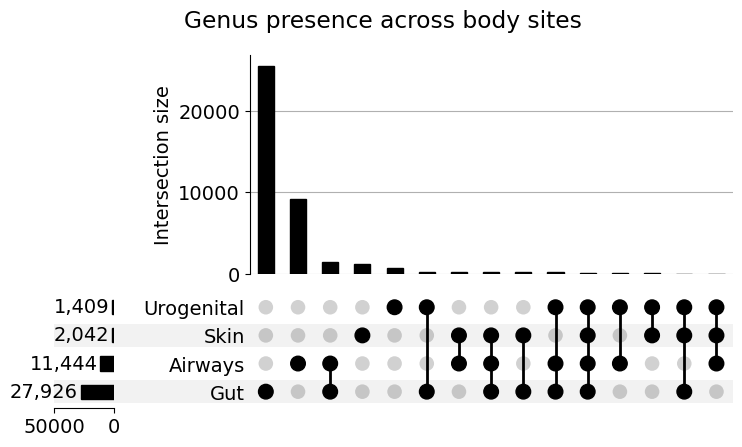

In [167]:
# Build species x body-site presence/absence matrix for UpSet
import polars as pl

upset_data = (
    combined
    .select(["genus_cluster_id", "body_site"])
    .filter(pl.col("genus_cluster_id").is_not_null() & pl.col("body_site").is_not_null() & (pl.col("body_site") != "Other"))
    .unique()
    .with_columns(pl.lit(1).alias("present"))
    .pivot(
        values="present",
        index="genus_cluster_id",
        on="body_site",
        aggregate_function="max"
    )
    .fill_null(0)
)

pdf = upset_data.to_pandas()
body_sites = [c for c in pdf.columns if c != "genus_cluster_id"]
pdf[body_sites] = pdf[body_sites].astype(bool)

# Convert boolean indicator columns to UpSet input format
from upsetplot import from_indicators

upset_input = from_indicators(body_sites, pdf)

from upsetplot import UpSet
import matplotlib.pyplot as plt

# Show only totals labels (set-size bars), not intersection bar labels
up = UpSet(
    upset_input,
    subset_size='count',
    sort_by='cardinality',
    show_counts=False,  # remove labels above intersection bars
    element_size=30,
    intersection_plot_elements=7
)
plot_result = up.plot()
# plot_result['intersections'].set_ylabel('Species intersection', fontdict={'fontweight': 'bold'})

# Add labels only to totals bars
totals_ax = plot_result.get('totals')
if totals_ax is not None:
    for container in totals_ax.containers:
        totals_ax.bar_label(container, fmt='{:,.0f}', label_type='edge', padding=2)

# extend x-axis labels to 100,000
totals_ax.set_xlim(50000, 0)
totals_ax.grid(False)
# plt.yscale('log')
plt.suptitle('Genus presence across body sites', fontdict={'fontweight': 'bold'})
plt.show()

/gscratch/pedslabs_hoffman/carsonjm/micromamba_envs/envs/lgonsa/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/gscratch/pedslabs_hoffman/carsonjm/micromamba_envs/envs/lgonsa/lib/python3.12/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never w

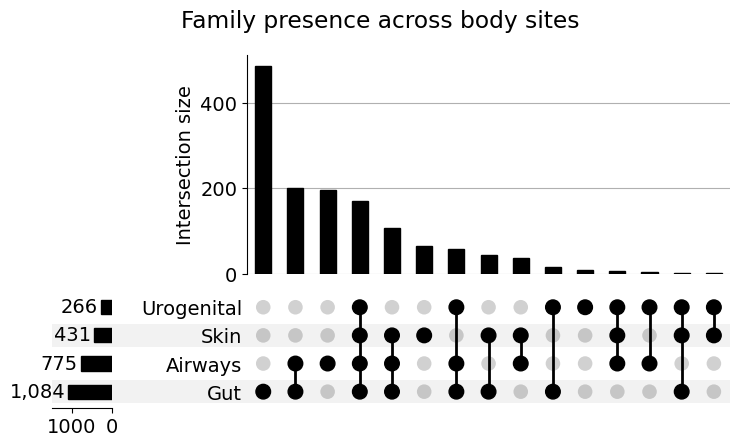

In [169]:
# Build species x body-site presence/absence matrix for UpSet
import polars as pl

upset_data = (
    combined
    .select(["family_cluster_id", "body_site"])
    .filter(pl.col("family_cluster_id").is_not_null() & pl.col("body_site").is_not_null() & (pl.col("body_site") != "Other"))
    .unique()
    .with_columns(pl.lit(1).alias("present"))
    .pivot(
        values="present",
        index="family_cluster_id",
        on="body_site",
        aggregate_function="max"
    )
    .fill_null(0)
)

pdf = upset_data.to_pandas()
body_sites = [c for c in pdf.columns if c != "family_cluster_id"]
pdf[body_sites] = pdf[body_sites].astype(bool)

# Convert boolean indicator columns to UpSet input format
from upsetplot import from_indicators

upset_input = from_indicators(body_sites, pdf)

from upsetplot import UpSet
import matplotlib.pyplot as plt

# Show only totals labels (set-size bars), not intersection bar labels
up = UpSet(
    upset_input,
    subset_size='count',
    sort_by='cardinality',
    show_counts=False,  # remove labels above intersection bars
    element_size=30,
    intersection_plot_elements=7
)
plot_result = up.plot()
# plot_result['intersections'].set_ylabel('Species intersection', fontdict={'fontweight': 'bold'})

# Add labels only to totals bars
totals_ax = plot_result.get('totals')
if totals_ax is not None:
    for container in totals_ax.containers:
        totals_ax.bar_label(container, fmt='{:,.0f}', label_type='edge', padding=2)

# extend x-axis labels to 100,000
totals_ax.set_xlim(1500, 0)
totals_ax.grid(False)
# plt.yscale('log')
plt.suptitle('Family presence across body sites', fontdict={'fontweight': 'bold'})
plt.show()